# Model output

In [1]:
import sys
sys.path.append('../..')
sys.path.append('..')

In [2]:
import os
import torch
import numpy as np
import pathlib

from modis.model import MODIS
from modis.utils.config import load_config
from modis.utils.data import get_dataloaders, summarize_dataset, get_samples_from_dataloader
from modis.utils.plots import plot_training_log, get_class_per_modality_colors, plot_2d_projection, plot_3d_projection, plot_confusion_matrix, calc_reconstruction_and_translation_mse

from src.intersim_dataset import get_datasets

In [3]:
# Adjust these variables
checkpoint_dir = pathlib.Path('../saved/checkpoints/intersim_2_delta/intersim/20250718_141125/')
config_file = pathlib.Path('../config/intersim.yaml')
use_best = True
save_plot = False

# Don't touch these
config = load_config(config_file)
checkpoint_file = checkpoint_dir / f"{'checkpoint_best.pth' if use_best else 'checkpoint_latest.pth'}"
num_modalities = len(config.modalities)
modality_names = [item.name for item in config.modalities]

## Plot training log

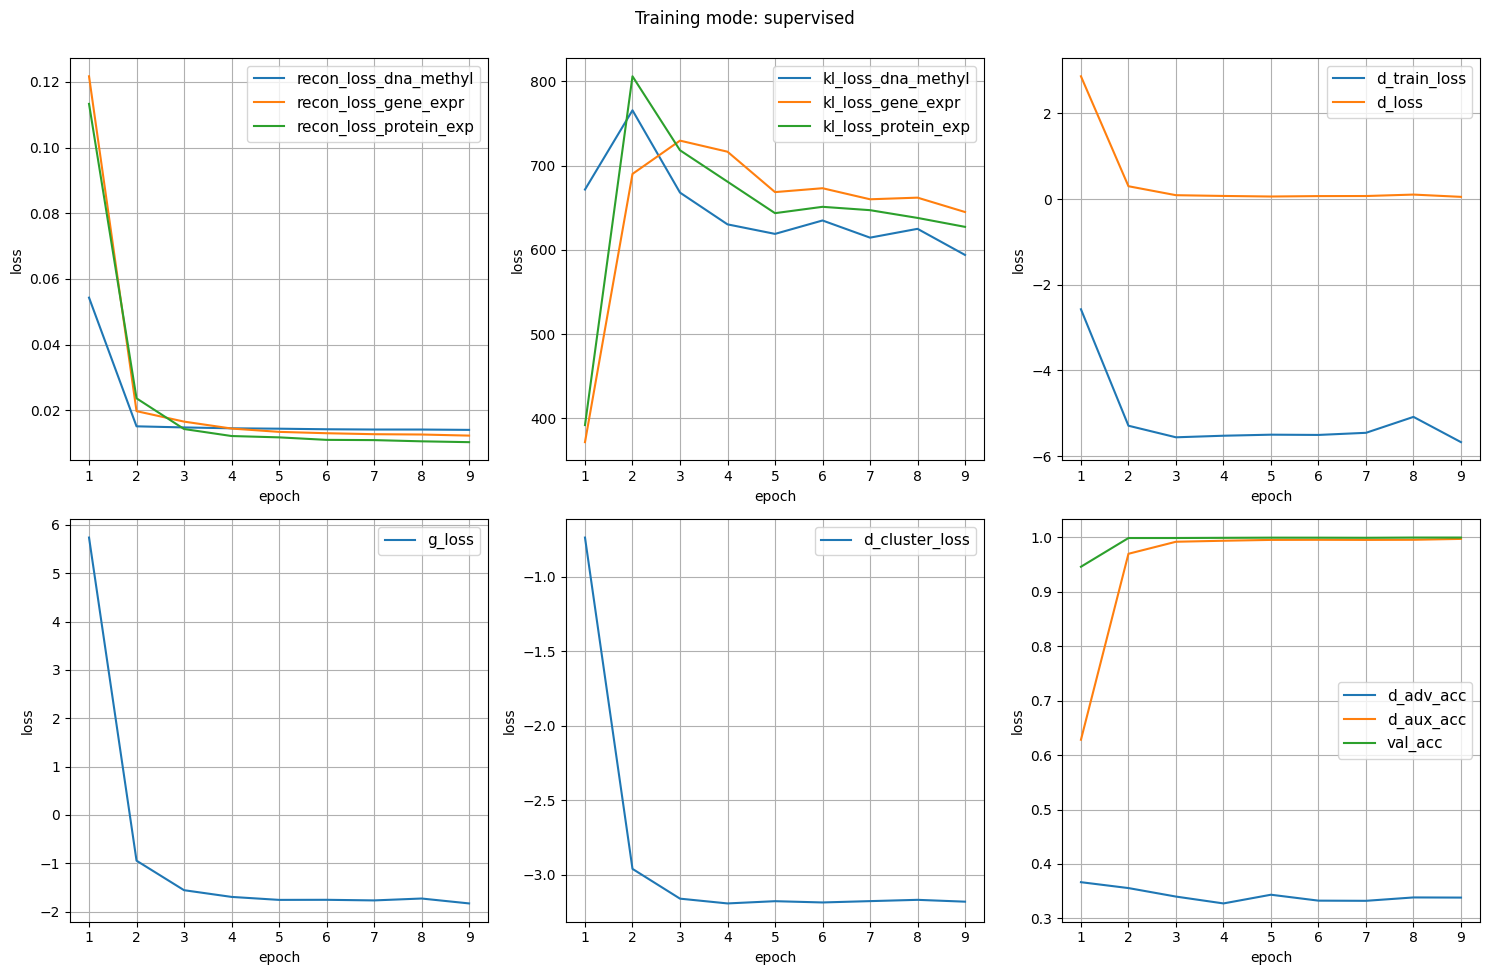

In [4]:
plot_training_log(
    training_mode = config.training_mode,
    modality_names = modality_names,
    checkpoint_dir = checkpoint_dir,
    use_best = use_best,
    save_plot = save_plot
)

## Load the model

In [5]:
model = MODIS(config)
model.load_from_checkpoint(checkpoint_file)

Model loaded from ../saved/checkpoints/intersim_2_delta/intersim/20250718_141125/checkpoint_best.pth


In [6]:
model.print_model_params()

dna_methyl VAE params: 1169787
gene_expr VAE params: 154751
protein_exp VAE params: 229328
Discriminator params: 724744
Total model params: 2278610


## Load the data

In [7]:
datasets = get_datasets(
    dataset_name = 'intersim_2_delta',
    pairing = 'paired',  ###
    split = 'test',  ###
    data_path = '../data',
    include_sample_ids = True
)

# Make semisupervised datasets
# from modis.utils.data import SemiSupervisedDataset
# datasets = [SemiSupervisedDataset(dataset, labeled_ratio=0.0) for dataset in datasets]

dataloaders = get_dataloaders(datasets, batch_size=config.batch_size, drop_last=False, shuffle=False)  # Shuffling breaks the reconstruction evaluation
summarize_dataset(dataloaders, modality_names=modality_names)

Dataset dna_methyl (2300 samples)
Samples per class: {0: 437, 1: 483, 2: 460, 3: 460, 4: 460}

Dataset gene_expr (2300 samples)
Samples per class: {0: 437, 1: 483, 2: 460, 3: 460, 4: 460}

Dataset protein_exp (2300 samples)
Samples per class: {0: 437, 1: 483, 2: 460, 3: 460, 4: 460}

Total samples: 6900: {0: 1311, 1: 1449, 2: 1380, 3: 1380, 4: 1380}


In [8]:
# Get a list of samples per modality
x, y = list(zip(*[get_samples_from_dataloader(dataloader, num_samples=None, device=config.device) for dataloader in dataloaders]))

# Remove unlabeled samples
if config.training_mode == 'semisupervised':
    x = list(x)
    y = list(y)
    for i in range(num_modalities):
        labeled_mask = torch.tensor([True if label != -1 else False for label in y[i]])
        x[i] = x[i][labeled_mask]
        y[i] = y[i][labeled_mask]

total_labeled_samples = sum([len(ds) for ds in y])
if total_labeled_samples == 0:
    raise Exception("At least some labeled samples are needed")

# Latents
modal_latents = [model.get_latents(x[i], input_modality=i) for i in range(num_modalities)]
latents = torch.concat(modal_latents, dim=0).cpu().numpy()

# Labels
class_labels = torch.concat(y, dim=0).cpu().numpy()
modality_labels = torch.concat([torch.full((x[i].shape[0],), i) for i in range(num_modalities)], dim=0).numpy()
class_per_modality_labels = [cl + mi*config.num_classes for mi, modality_class_labels in enumerate(y) for cl in modality_class_labels.cpu().numpy()]  ####### Assuming equal number of classes per modality

# Colors
modality_colors = get_class_per_modality_colors(num_modalities=1, num_classes=num_modalities)
class_colors = get_class_per_modality_colors(num_modalities=1, num_classes=config.num_classes)
class_per_modality_colors = get_class_per_modality_colors(num_modalities=num_modalities, num_classes=config.num_classes)

# Names
modality_names = [f"{config.modalities[i].name}" for i in range(num_modalities)]
class_names = [i for i in range(config.num_classes)]
class_per_modality_names = [f"{config.modalities[mi].name}_{ci}" for mi in range(num_modalities) for ci in range(config.num_classes)]

## Plot projections

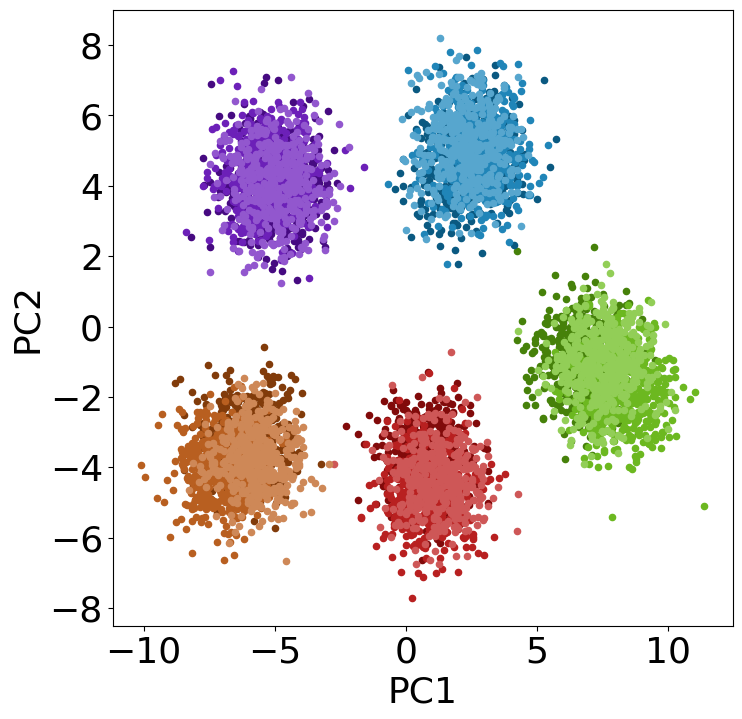

In [9]:
plot_2d_projection(
    technique = 'pca',
    data = latents,
    labels = class_per_modality_labels,
    labels_colors = class_per_modality_colors,
    labels_names = class_per_modality_names,
    standardize = False,
    checkpoint_dir = checkpoint_dir,
    is_best = use_best,
    save_plot = save_plot,
    text_size = 26
)

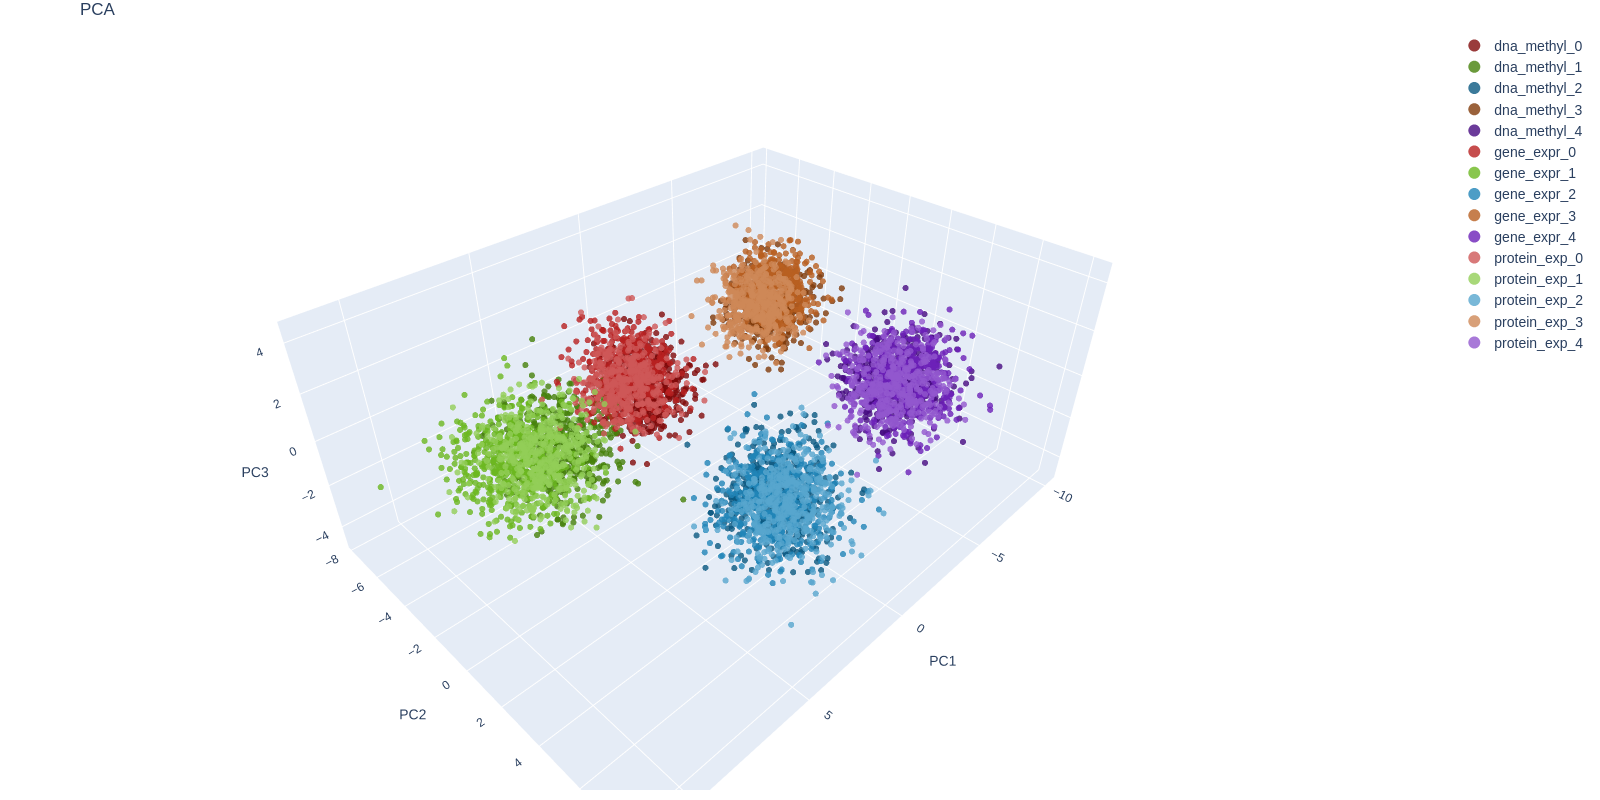

In [10]:
plot_3d_projection(
    technique = 'pca',
    data = latents,
    labels = class_per_modality_labels,
    labels_colors = class_per_modality_colors,
    labels_names = class_per_modality_names,
    standardize = False,
    checkpoint_dir = checkpoint_dir,
    is_best = use_best,
    save_plot = save_plot
)

## Confusion matrices

In [11]:
class_pred, modality_pred = model.discriminator.predict(torch.tensor(latents).to(config.device), include_modality_pred=True)
class_pred = class_pred.cpu().numpy()
modality_pred = modality_pred.cpu().numpy()
class_per_modality_labels_pred = np.array([
    class_pred + modality * config.num_classes
    for class_pred, modality in zip(class_pred, modality_pred)
])

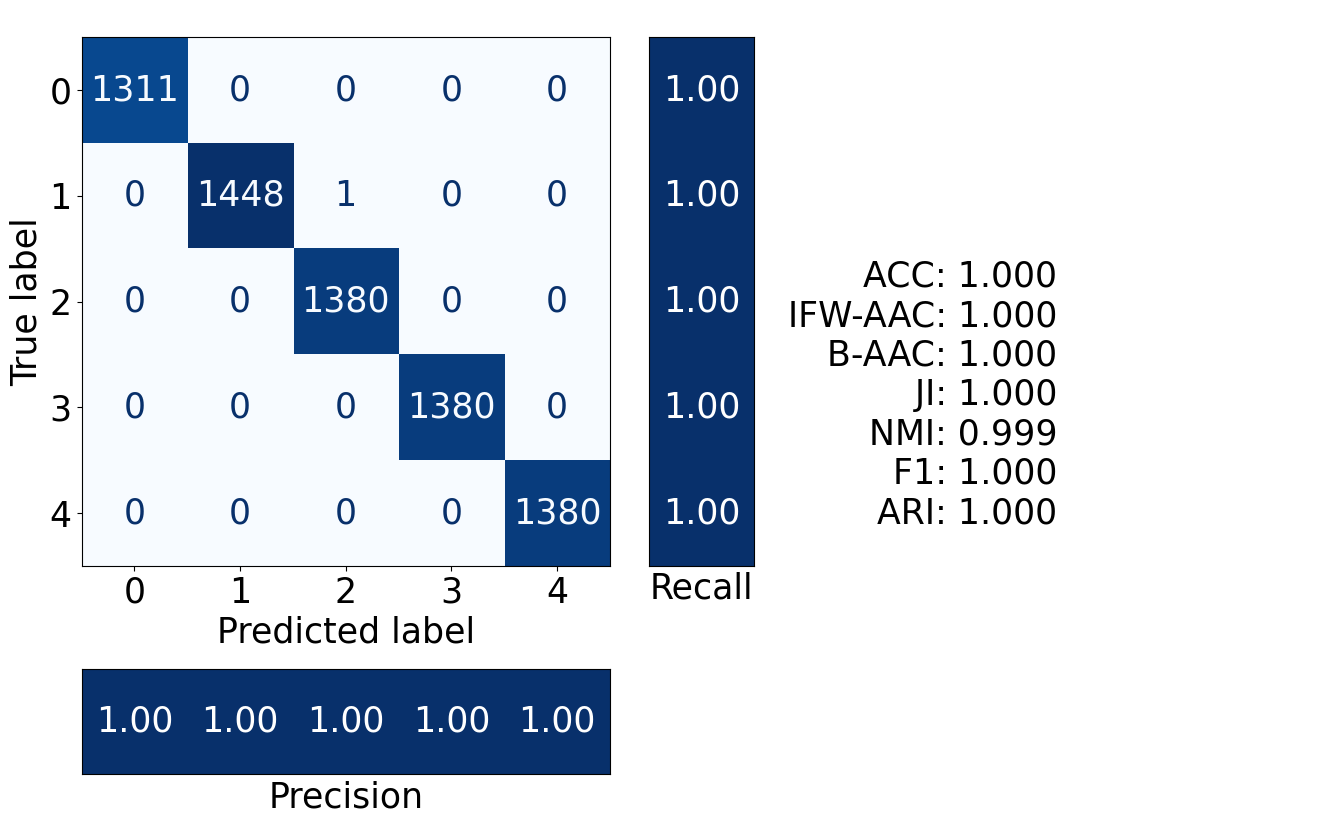

In [12]:
plot_confusion_matrix(
    class_labels,
    class_pred,
    performance_metrics = True,
    checkpoint_dir = checkpoint_dir,
    is_best = use_best,
    save_plot = save_plot,
    figsize = (16, 10),
    text_size = 25
)

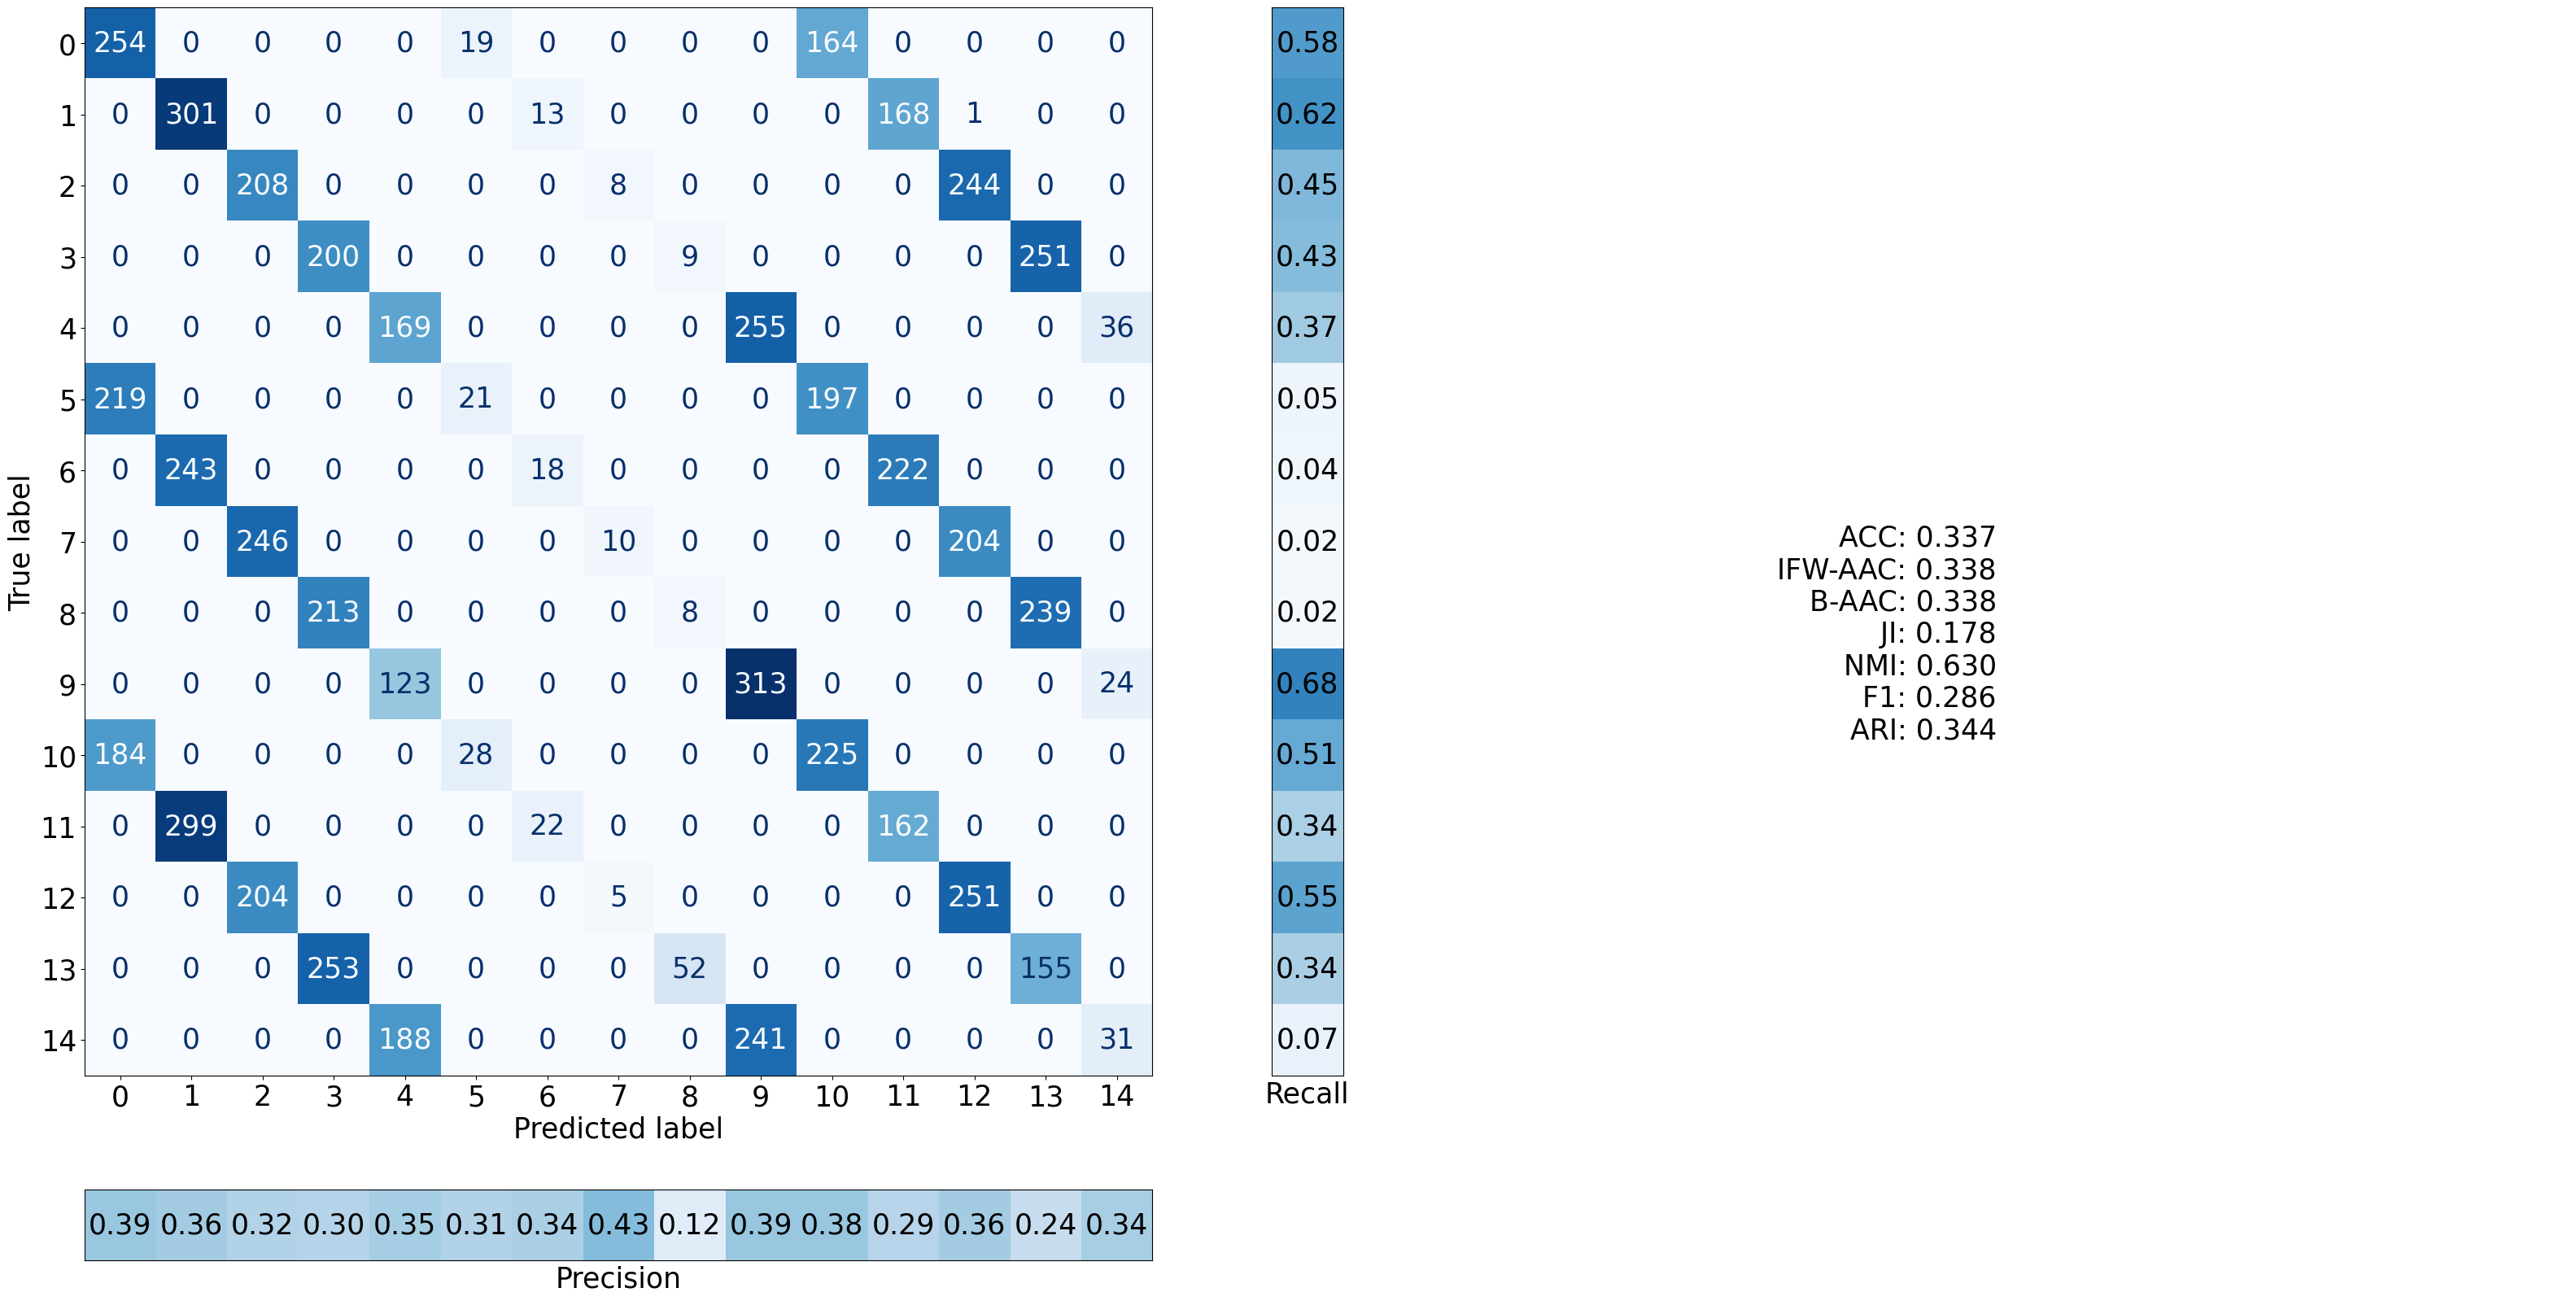

In [13]:
plot_confusion_matrix(
    class_per_modality_labels,
    class_per_modality_labels_pred,
    performance_metrics = True,
    checkpoint_dir = checkpoint_dir,
    is_best = use_best,
    save_plot = save_plot,
    figsize = (40, 20),
    text_size = 25,
    filename_suffix = 'class_per_modality'
)

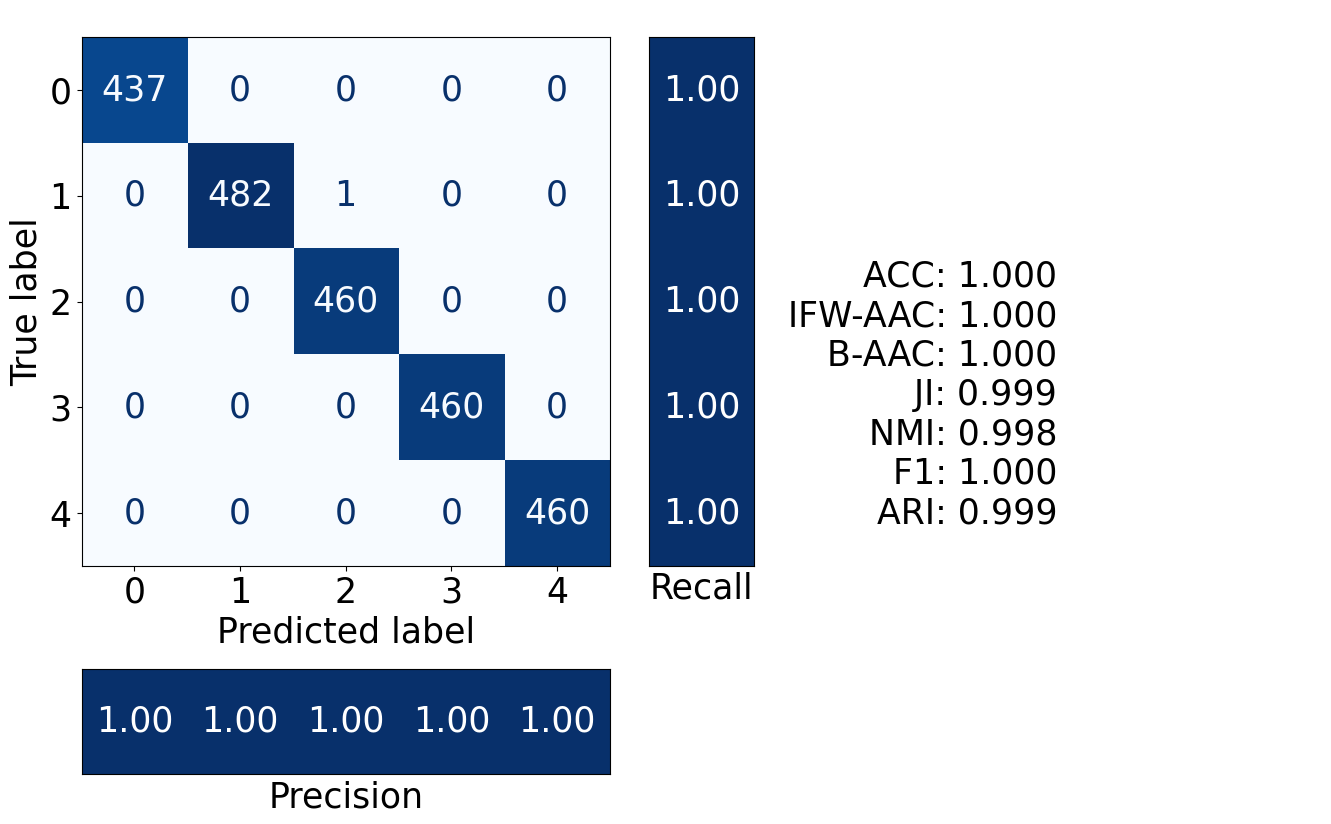

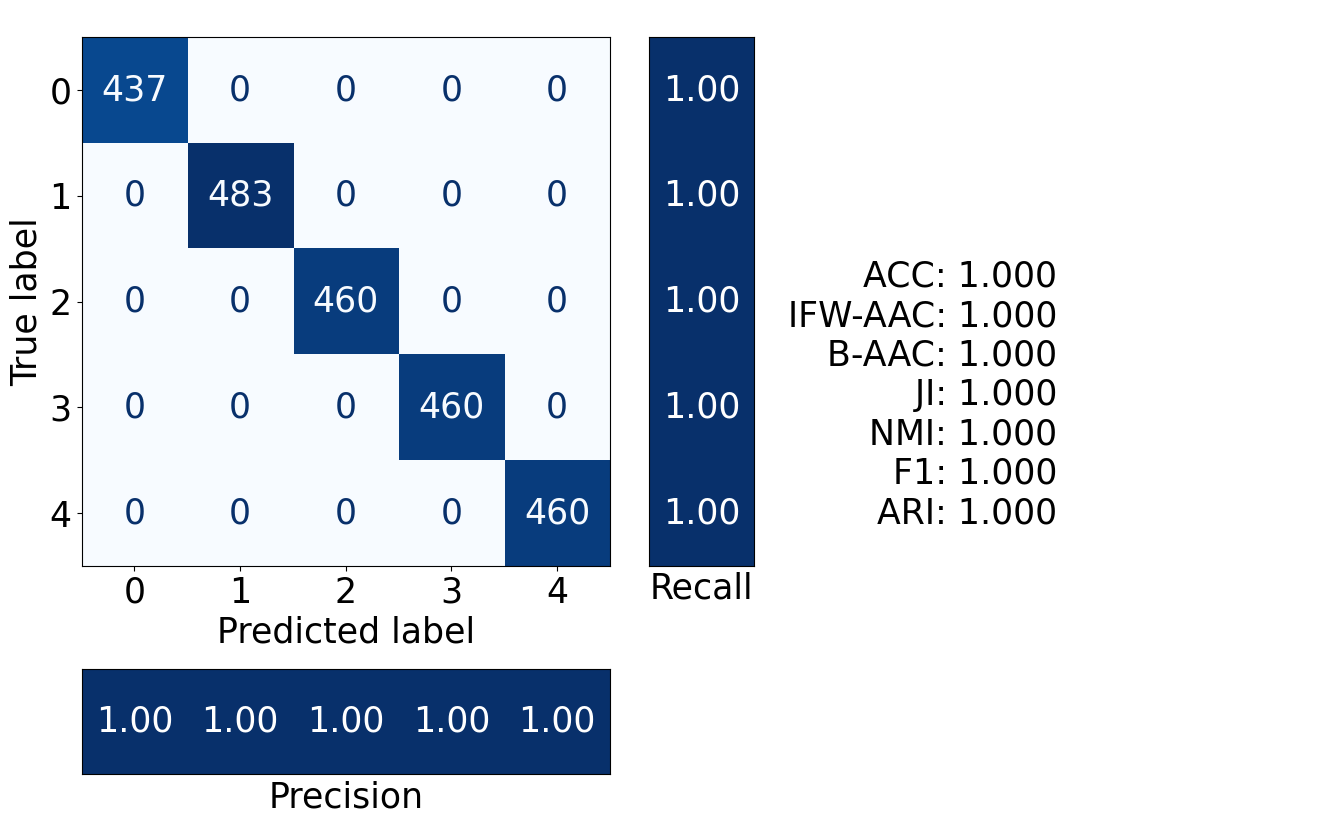

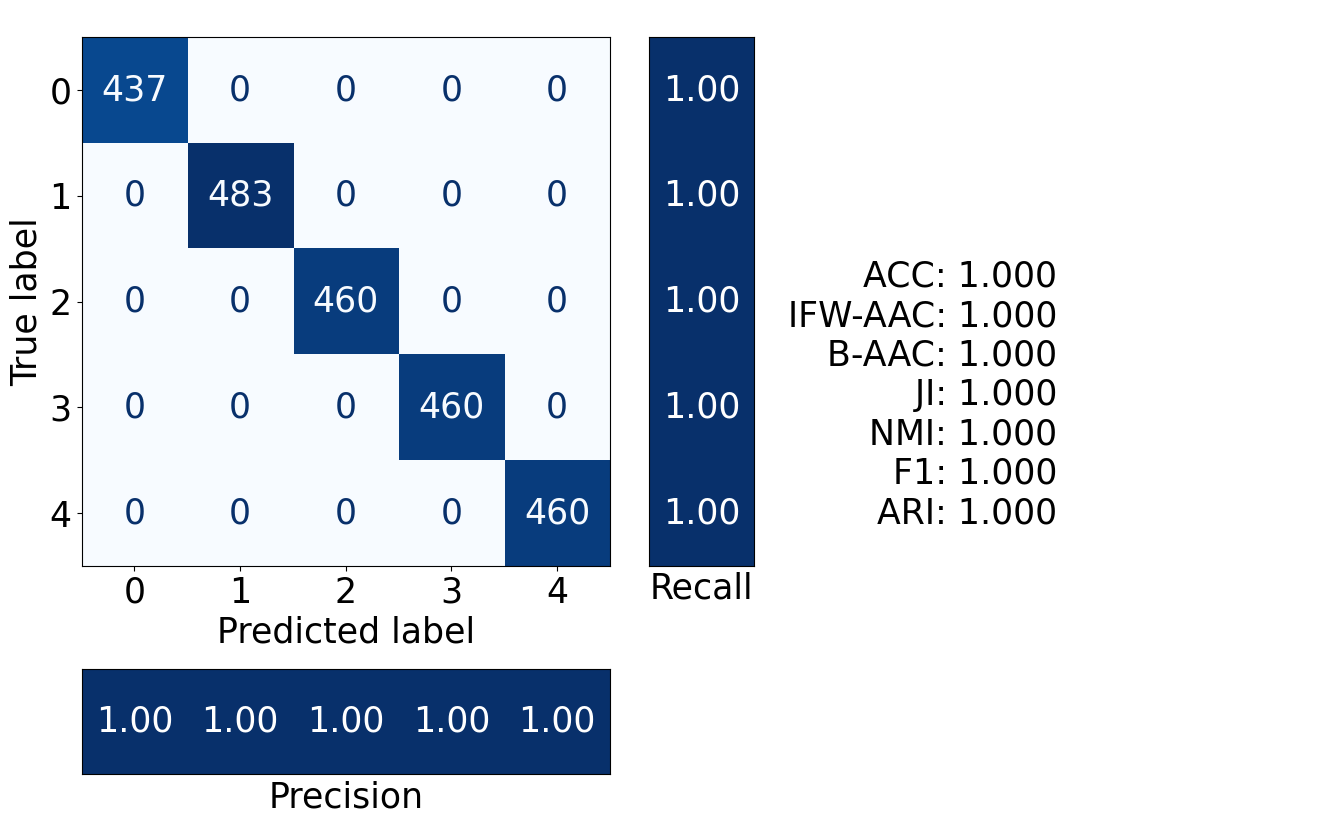

In [14]:
for i in range(num_modalities):
    plot_confusion_matrix(
        class_labels[modality_labels == i],
        class_pred[modality_labels == i],
        performance_metrics = True,
        checkpoint_dir = checkpoint_dir,
        is_best = use_best,
        save_plot = save_plot,
        figsize = (16, 10),
        text_size = 25,
        filename_suffix = f'modality_{modality_names[i]}'
    )

## Reconstruction

**Important**:
- The dataset must be paired so that the reconstructions are comparable, and samples across modalities must be aligned
- all_pairs_mse function requires a lot of memory

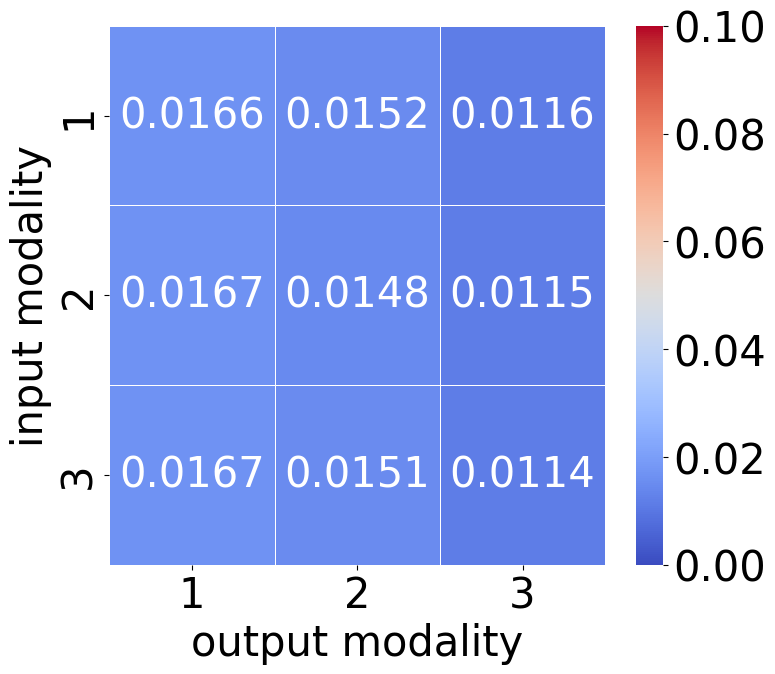

In [15]:
calc_reconstruction_and_translation_mse(x, model, save_plot=save_plot)